# 05 Transformer (PyTorch) - Tesla Market Analysis

This is a complete, standalone pipeline for training a Transformer-based model to identify market regimes in Tesla trading data.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid')

### 1. Data Windowing & Normalization

In [2]:
def prepare_transformer_data(path, window=30):
    df = pd.read_csv(path).dropna()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[['Close', 'RSI', 'Volatility_20d']])
    
    X, y = [], []
    for i in range(len(scaled) - window):
        X.append(scaled[i:i+window])
        y.append(scaled[i+window, 0])
    return np.array(X), np.array(y)

X, y = prepare_transformer_data('../_data/stock_tesla.csv')
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

### 2. Transformer Architecture Definition

In [3]:
class MarketTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim=32, nhead=4):
        super().__init__()
        self.proj = nn.Linear(input_dim, embed_dim)
        self.pos_enc = nn.Parameter(torch.zeros(1, 30, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Linear(embed_dim, 1)
        
    def forward(self, x):
        x = self.proj(x) + self.pos_enc
        x = self.transformer(x)
        return self.head(x[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MarketTransformer(3).to(device)
train_loader = DataLoader(list(zip(torch.tensor(X_train, dtype=torch.float32), 
                                   torch.tensor(y_train, dtype=torch.float32).view(-1, 1))), 
                          batch_size=32, shuffle=False)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 3. Training Loop

In [4]:
model.train()
for epoch in range(20):
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0: print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

Epoch 5, Loss: 0.099878
Epoch 10, Loss: 0.077170
Epoch 15, Loss: 0.022659
Epoch 20, Loss: 0.069205


### 4. Evaluation & Visuals

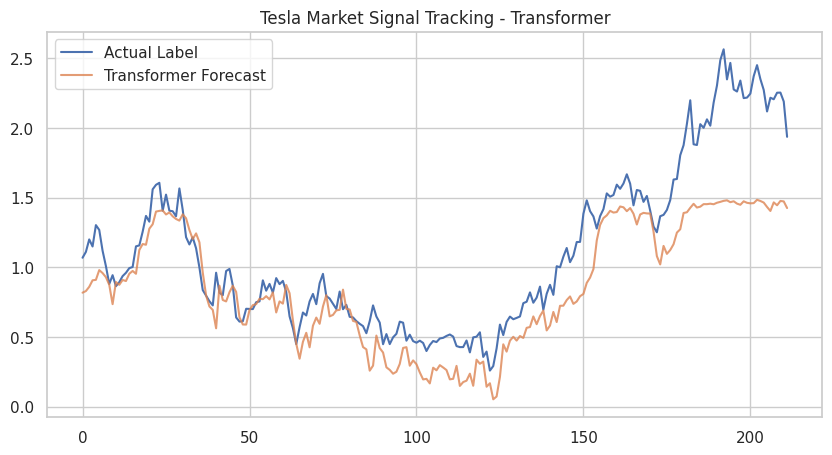

In [5]:
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy()

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual Label')
plt.plot(y_pred, label='Transformer Forecast', alpha=0.8)
plt.title('Tesla Market Signal Tracking - Transformer')
plt.legend()
plt.show()

### 5. Model Saving

In [6]:
torch.save(model.state_dict(), '../_model/tesla_trading_transformer.pth')
print("Transformer Model saved.")

Transformer Model saved.
